## Laboratorio 7: Aprendizaje no supervisado, semi-supervisado y activo usando K-Means

## 1. Aprendizaje no supervisado

Generamos un conjunto de datos sintético.

Se generaron 17
Coordenadas de los centroides:
[[ 7.97649553 -4.08161879]
 [ 1.47056736  2.9552175 ]
 [ 2.2594768  -9.20154332]
 [-2.5060362   1.0693896 ]
 [ 8.83386632 -7.63749719]
 [-8.74610968 -7.25813279]
 [-9.81253197  0.02427416]
 [ 1.79552489  6.78553869]
 [ 4.61160556  3.01123007]
 [ 3.59217388 -0.2907042 ]
 [-6.34488258 -9.75799204]
 [ 0.1230329   9.64649266]
 [ 3.61050969  5.30920765]
 [ 6.50721584  5.12743049]
 [ 4.28827161  7.38951382]
 [-4.89586981  9.82490797]
 [ 6.44947661  0.38775793]]


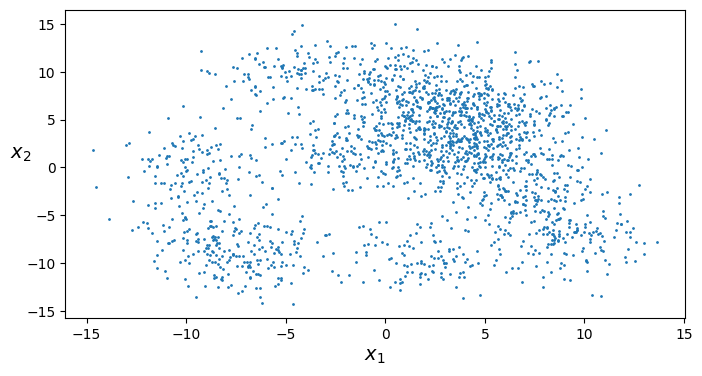

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(5, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

Entrenamos el modelo usando K-Means y mostramos las coordenadas de los centroides.

In [3]:
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

kmeans.cluster_centers_

array([[ -9.11628212,  -8.18852179],
       [  7.34546627,   3.73478255],
       [  9.44881145,  -7.67914324],
       [  0.76305846,  10.51234403],
       [ -2.91400843,   1.574794  ],
       [  4.67184874,   0.07851423],
       [  3.66889278,   3.89200779],
       [ -9.71610113,   1.88065088],
       [  1.59251978,  -6.55241099],
       [ -9.30729505,  -2.59781832],
       [ -4.95208663,   9.95718302],
       [  5.1782276 ,   7.7480876 ],
       [ -5.58322912,  -9.68861259],
       [  0.81066693,   1.13954292],
       [  7.70611812,  -2.91289169],
       [  2.76990622, -10.41806223],
       [  0.76515198,   6.3202953 ]])

Generamos nuevas ubicaciones y K-Means devuelve las etiquetas para dichas ubicaciones (*hard clustering*).

In [4]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])  #Predecir nuevas ubicaciones
kmeans.predict(X_new)

array([13,  6,  4,  4], dtype=int32)

Generamos una gráfica que muestre los centroides y las fronteras de decisión.

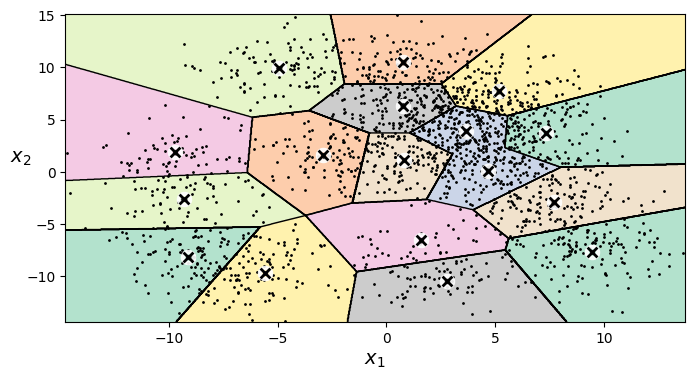

In [5]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Manera alternativa de asignar una etiqueta o grupo a una muestra utilizando *soft clustering* (puntuación) en función de su distancia al centroide.

In [6]:
kmeans.transform(X_new)  # la  distancia de cada punto del X_new

array([[13.67159742,  7.54753902, 13.52648704,  8.54647642,  2.94486761,
         5.05156196,  4.12801014,  9.71683412,  8.69941682, 10.38102473,
         9.37229553,  7.73657238, 12.95361384,  1.18218749,  9.13896937,
        12.72323269,  4.38752881],
       [15.83067493,  4.67894728, 11.63069142,  8.80135833,  5.92927448,
         2.54699544,  2.00676631, 12.7166612 ,  8.66745258, 13.13809137,
        11.24955303,  6.14696564, 14.50156841,  2.35235322,  6.80323838,
        12.42019375,  4.86410292],
       [12.75115394, 10.37152726, 16.40173792,  8.40213793,  1.42779784,
         8.2092839 ,  6.72828424,  6.8087412 , 10.59904682,  8.43312165,
         7.22585896,  9.45662427, 12.9488981 ,  4.24057579, 12.23042327,
        14.60603341,  5.0200329 ],
       [12.3147637 , 10.41889439, 16.08066738,  8.85202044,  0.92919357,
         8.04492737,  6.81262186,  6.74459841, 10.15073311,  8.10985342,
         7.70845126,  9.71729541, 12.45934787,  4.04623602, 11.99668127,
        14.14807936

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.

KMeans(algorithm='elkan', max_iter=1, n_clusters=17, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=17, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=17, n_init=1, random_state=5)


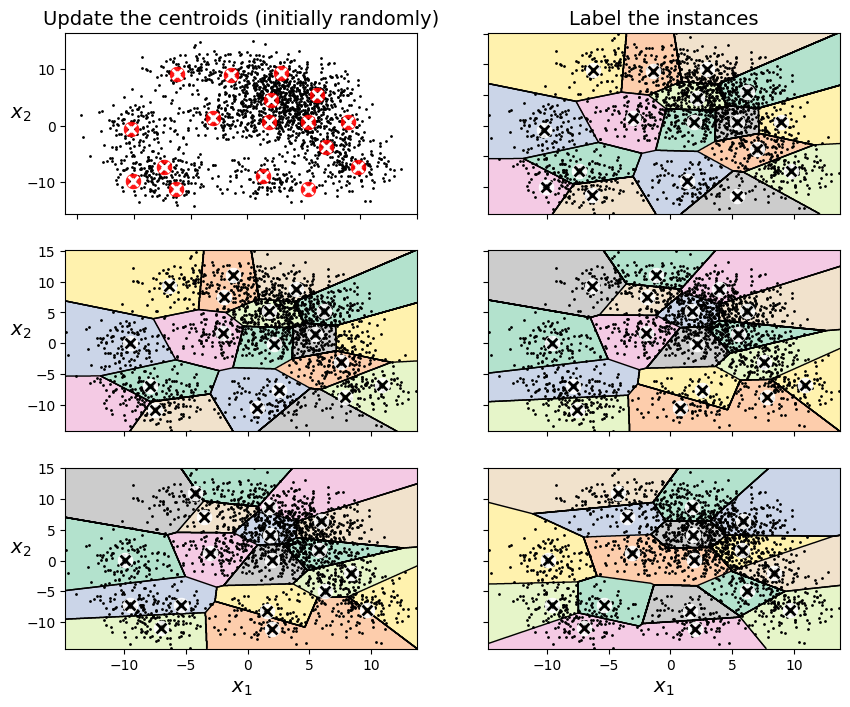

In [7]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=1, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=5)

kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función de su estado inicial, el algoritmo puede llegar a una solución u otra.

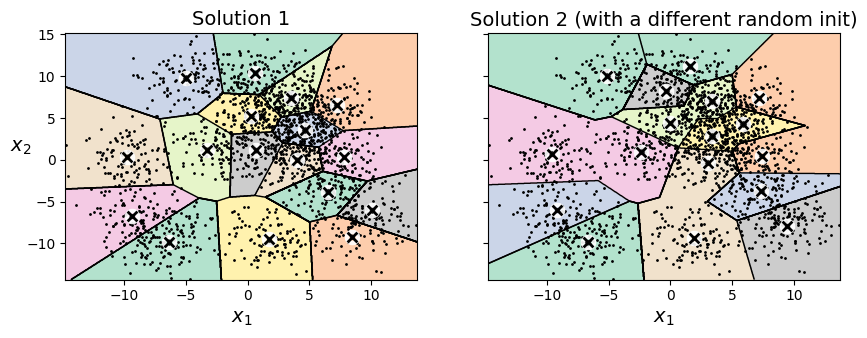

In [9]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

## Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el silhouette score, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.


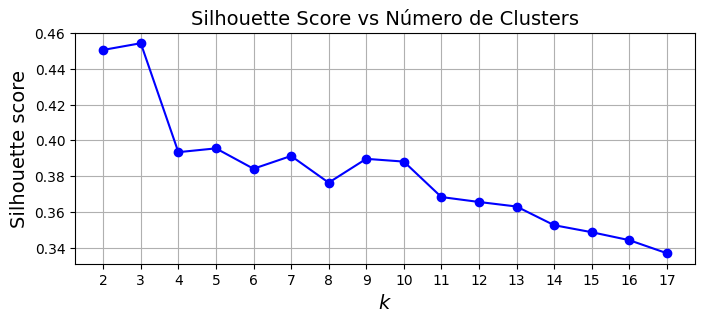

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.xticks(ks)
plt.grid(True)
plt.show()

## Método del codo:

Calcula la inercia para distintos valores de *k*

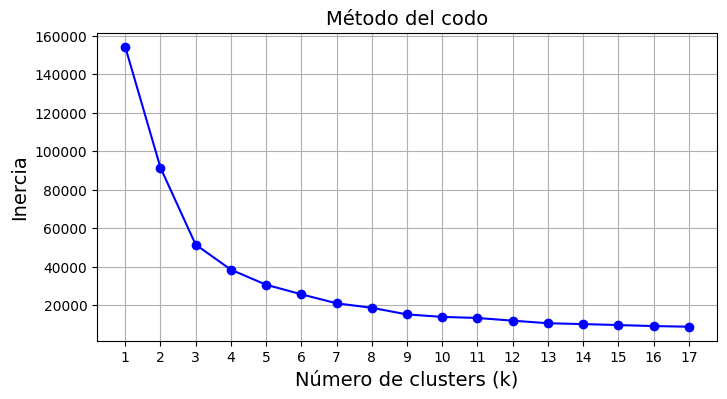

In [11]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.xticks(K)
plt.grid(True)
plt.show()

## Diagramas de silueta:

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

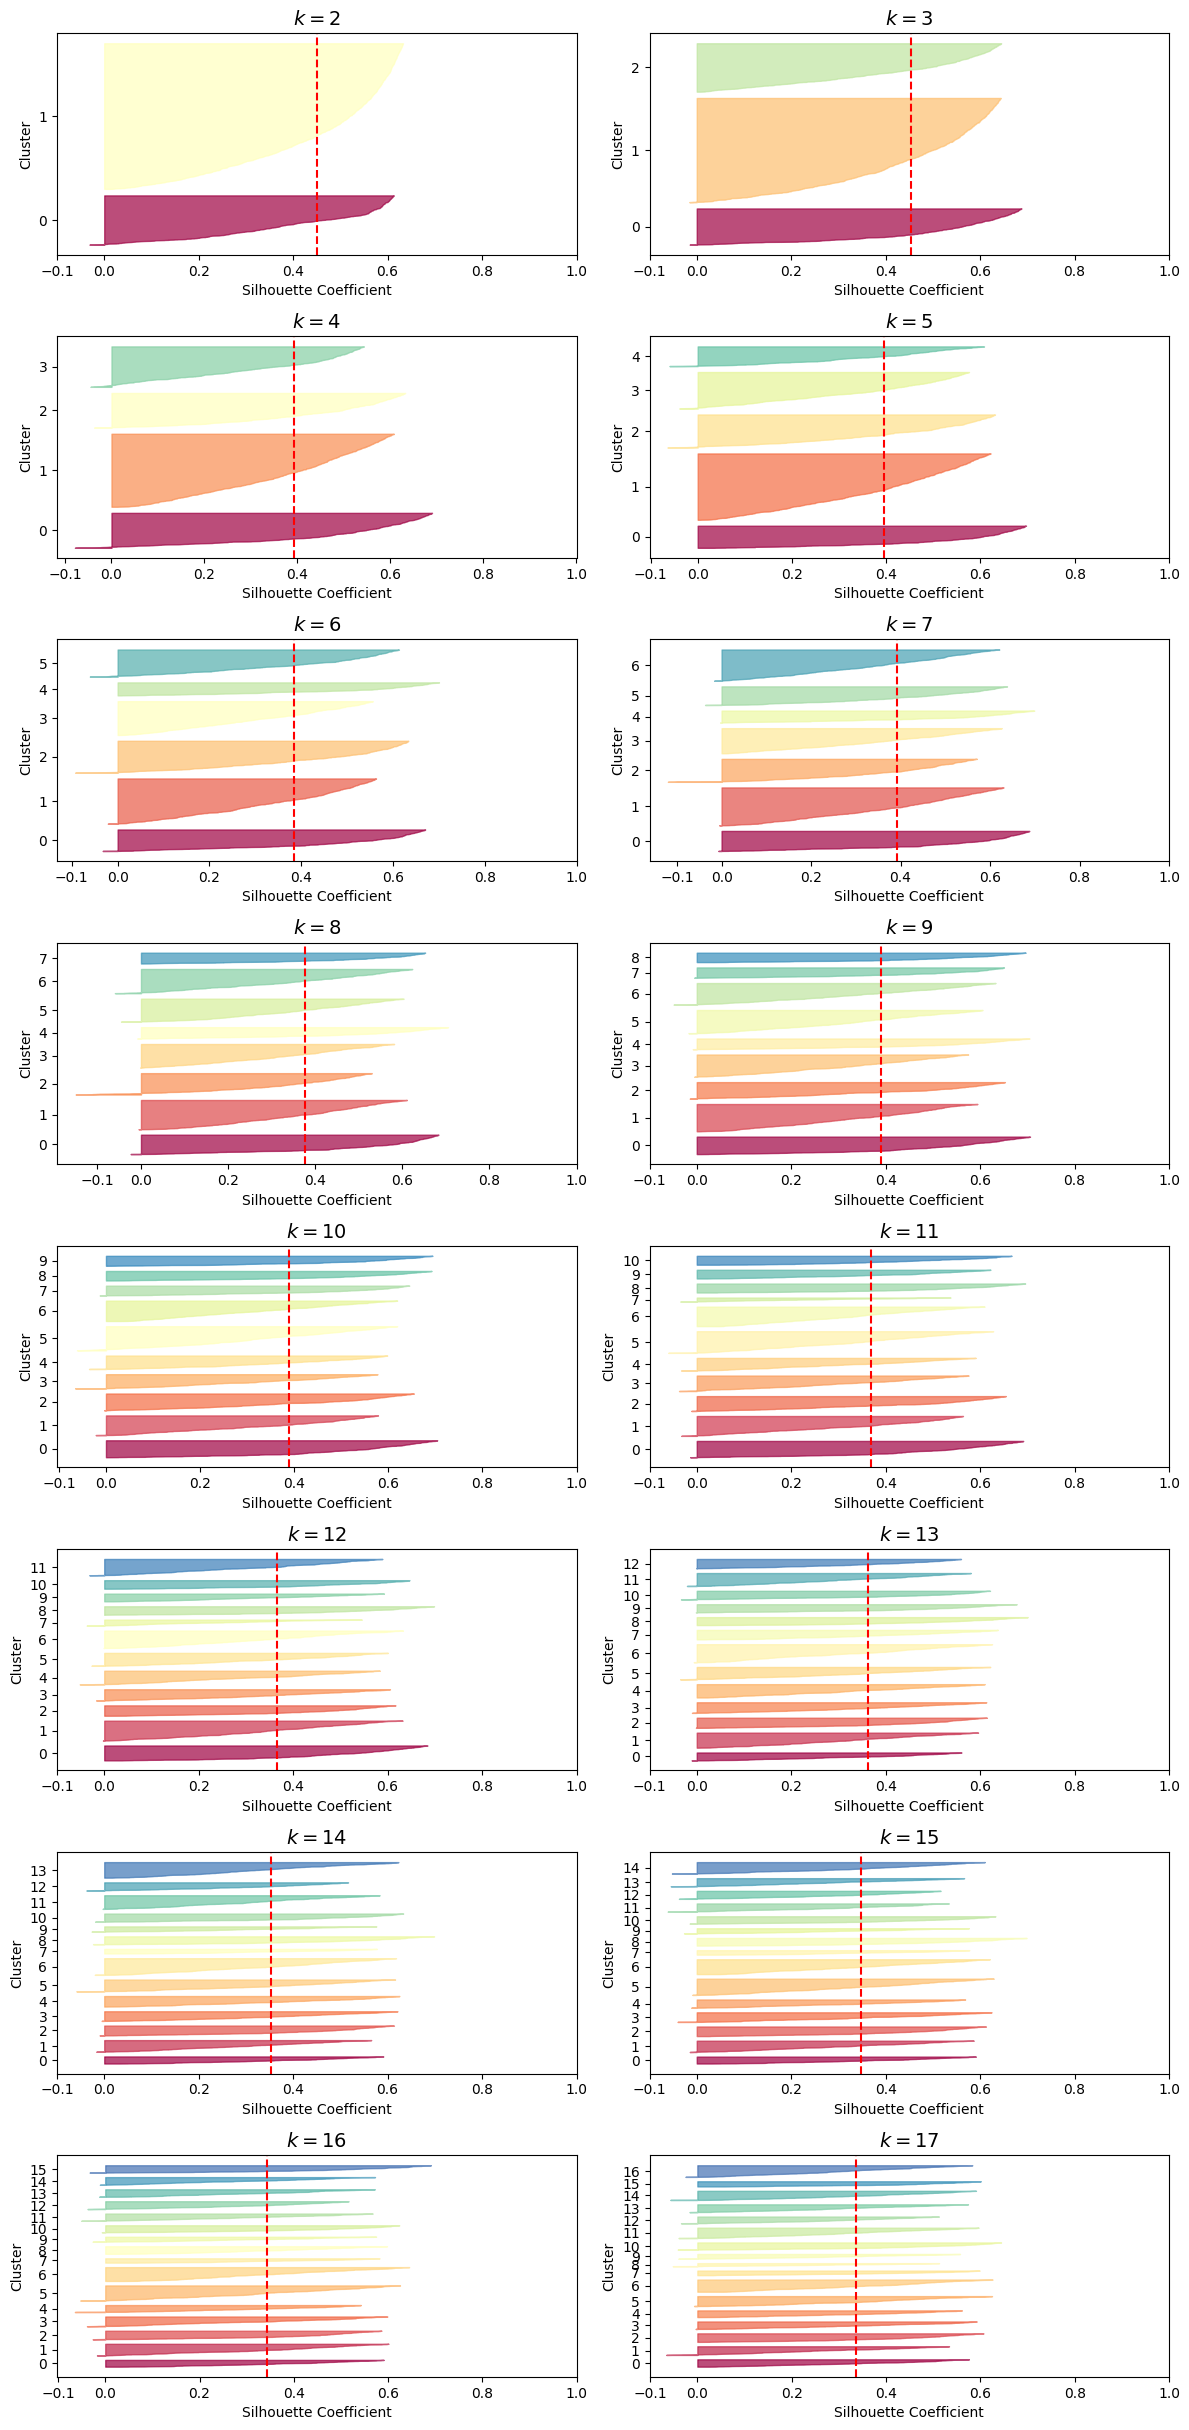

In [12]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

## 2. Aprendizaje semi-supervisado

El aprendizaje semi-supervisado, también conocido como Semi-supervised Learning, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset bloodMNIST y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.

In [13]:
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

data = np.load("/content/drive/MyDrive/MachineLearning/datasets/lab7/chestmnist_64a.npz")

train_images = data["train_images"]
train_labels = data["train_labels"].squeeze()
val_images   = data["val_images"]
val_labels   = data["val_labels"].squeeze()
test_images  = data["test_images"]
test_labels  = data["test_labels"].squeeze()

train_images_flat = train_images.reshape(len(train_images), -1)
val_images_flat   = val_images.reshape(len(val_images), -1)
test_images_flat  = test_images.reshape(len(test_images), -1)

X_train_full = np.vstack([train_images_flat, val_images_flat])
y_train_full = np.vstack([train_labels, val_labels]).astype(np.int64)

X_test = test_images_flat
y_test = test_labels.astype(np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Mounted at /content/drive
X_train shape: (89820, 4096)
y_train shape: (89820, 14)
X_val shape: (22455, 4096)
X_test shape: (22433, 4096)
y_test shape: (22433, 14)


Imagina que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, 50 grupos. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.

In [32]:
from sklearn.cluster import MiniBatchKMeans

k = 300

kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=256)
X_digits_dist = kmeans.fit_transform(X_train)

print(X_digits_dist.shape)
print(X_digits_dist)

(89820, 300)
[[4099.399  2255.4116 3143.1267 ... 4257.4775 3724.2915 4330.447 ]
 [4605.767  4486.0625 4441.828  ... 4496.368  5171.114  3364.6167]
 [2825.8242 2044.3131 3349.5442 ... 2481.3428 2573.419  3786.0542]
 ...
 [4283.952  3832.5454 3169.3164 ... 4317.908  4775.346  3798.422 ]
 [3848.5547 2707.4937 3826.0881 ... 3896.8633 3178.453  4703.555 ]
 [3623.1118 2967.9915 2848.0137 ... 3113.4846 4476.178  4329.0493]]


In [33]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

In [34]:
print(X_representative_digits.shape)
print(X_representative_digits)

(300, 4096)
[[ 48.  34.  32. ...   0.   1.   3.]
 [  4.   4.   4. ...  16.  44.  77.]
 [  1.   1.   1. ... 150. 140. 126.]
 ...
 [ 68.  22.  16. ...  84.  52.  50.]
 [  7.   8.   8. ...   0.   0.   0.]
 [ 37.  35.  33. ...  20.  24.  27.]]


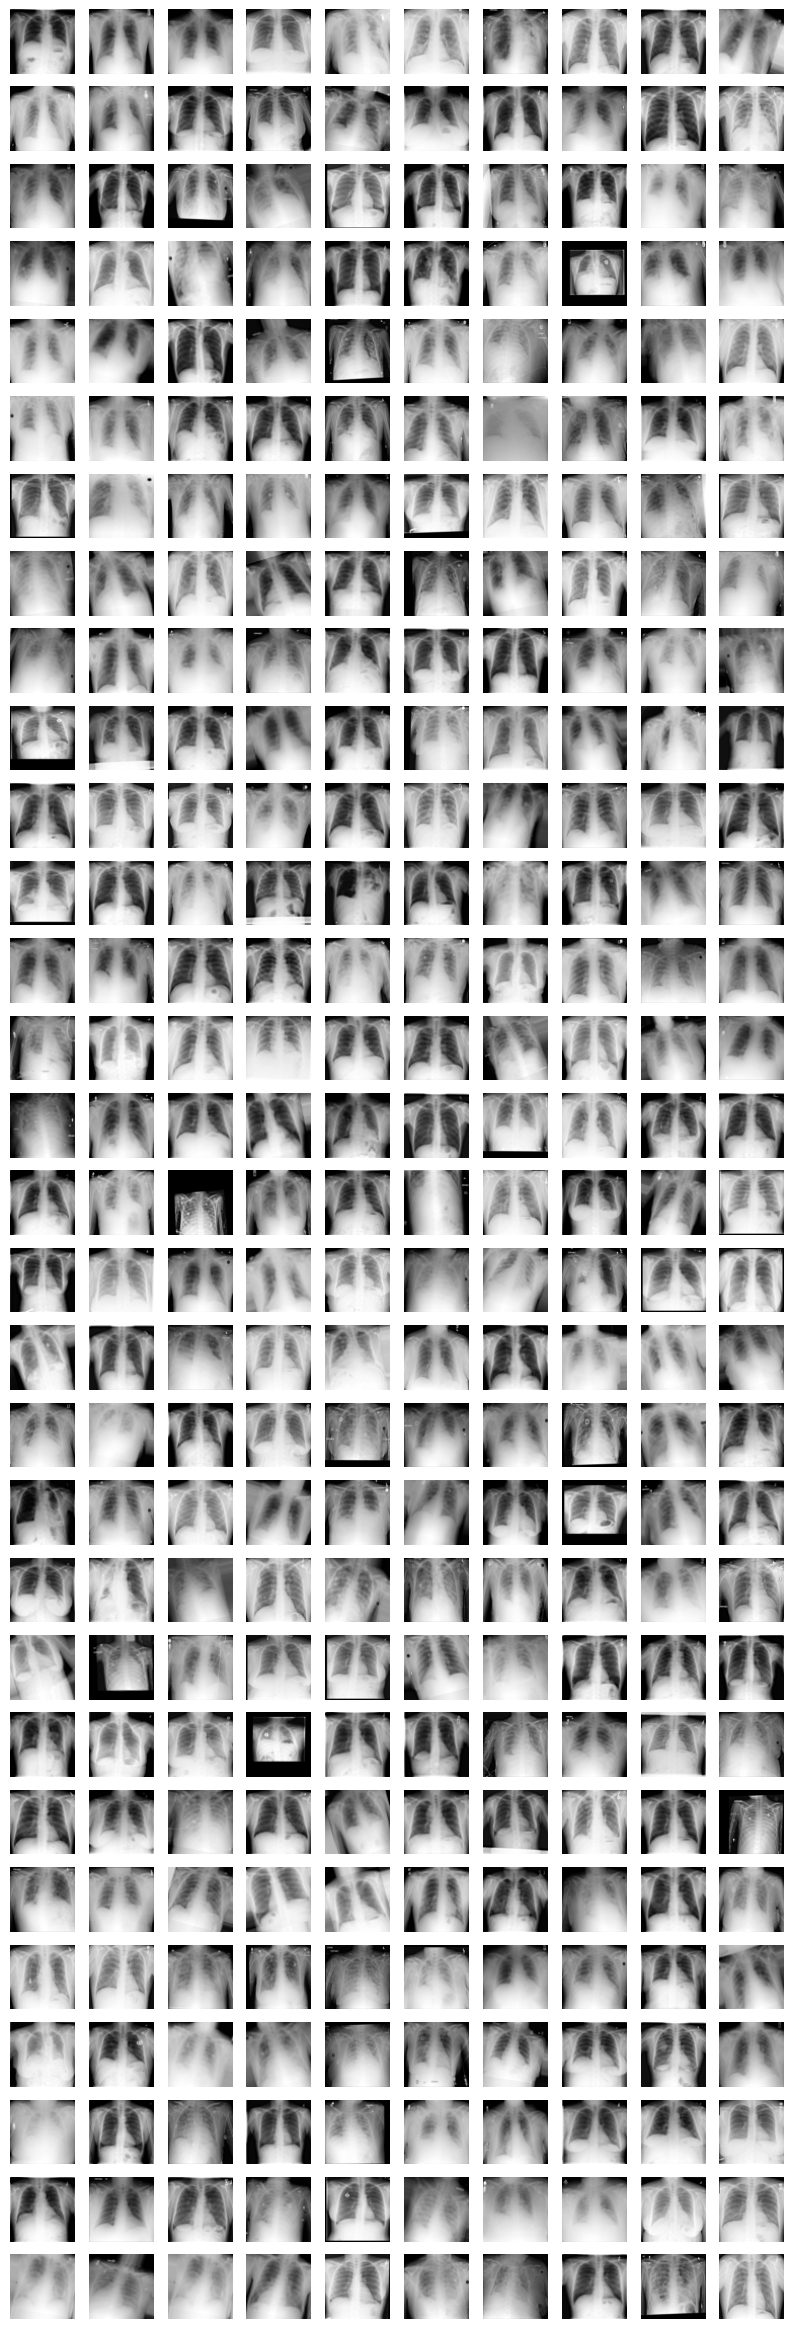

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 30))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(30, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(64, 64), cmap='gray')
    plt.axis('off')
plt.show()

El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [37]:
y_representative_digits = y_train[idxs]

Y entrenaremos un clasificador usando estas imágenes representativas.

In [53]:
from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, np.argmax(y_representative_digits, axis=1))
log_reg2.score(X_test, np.argmax(y_test, axis=1))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 23.6 s, sys: 21.8 ms, total: 23.6 s
Wall time: 14.4 s


0.4457272767797441

Como puedes observar hemos obtenido una precisión de casi el 45% habiendo anotado 300 imágenes, pero aquellas más representativas. Entrenar el mismo modelo con 300 imágenes aleatorias nos daría peores resultados.

In [57]:
idxs = np.random.choice(len(X_train), 300, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[idxs], np.argmax(y_train[idxs], axis=1))
log_reg.score(X_test, np.argmax(y_test, axis=1))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 17.7 s, sys: 16.7 ms, total: 17.7 s
Wall time: 11.4 s


0.47902643427094016

A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los más útiles y representativos. Una vez que hemos entrenado un clasificador con las imágenes más representativas, podemos aprovecharlo para etiquetar automáticamente el resto del conjunto. Para ello, asignamos a todas las imágenes de cada grupo la misma etiqueta que le dimos a su representante.

In [58]:
y_train_propagated = np.empty(len(X_train), dtype=int)
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = np.argmax(y_representative_digits[i])

In [59]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_test, np.argmax(y_test, axis=1))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 7s, sys: 90.4 ms, total: 1min 8s
Wall time: 41.8 s


0.4420273703918335

A veces, al intentar mejorar el modelo añadiendo más datos etiquetados automáticamente, el resultado puede ser peor. Esto ocurre porque no todas las imágenes quedan bien agrupadas y se introduce ruido en el entrenamiento. Para evitarlo, podemos limitar el etiquetado solo a las muestras que estén más cerca de los representantes de cada grupo, o bien recurrir a técnicas de aprendizaje activo para seleccionar mejor qué ejemplos anotar.

## Aprendizaje Activo

El aprendizaje activo (o Active Learning) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.


In [60]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.99906003, 0.99920103, 0.99922878, 0.9993591 , 0.99943417,
       0.9994352 , 0.99944835, 0.99947675, 0.99949813, 0.9995051 ])

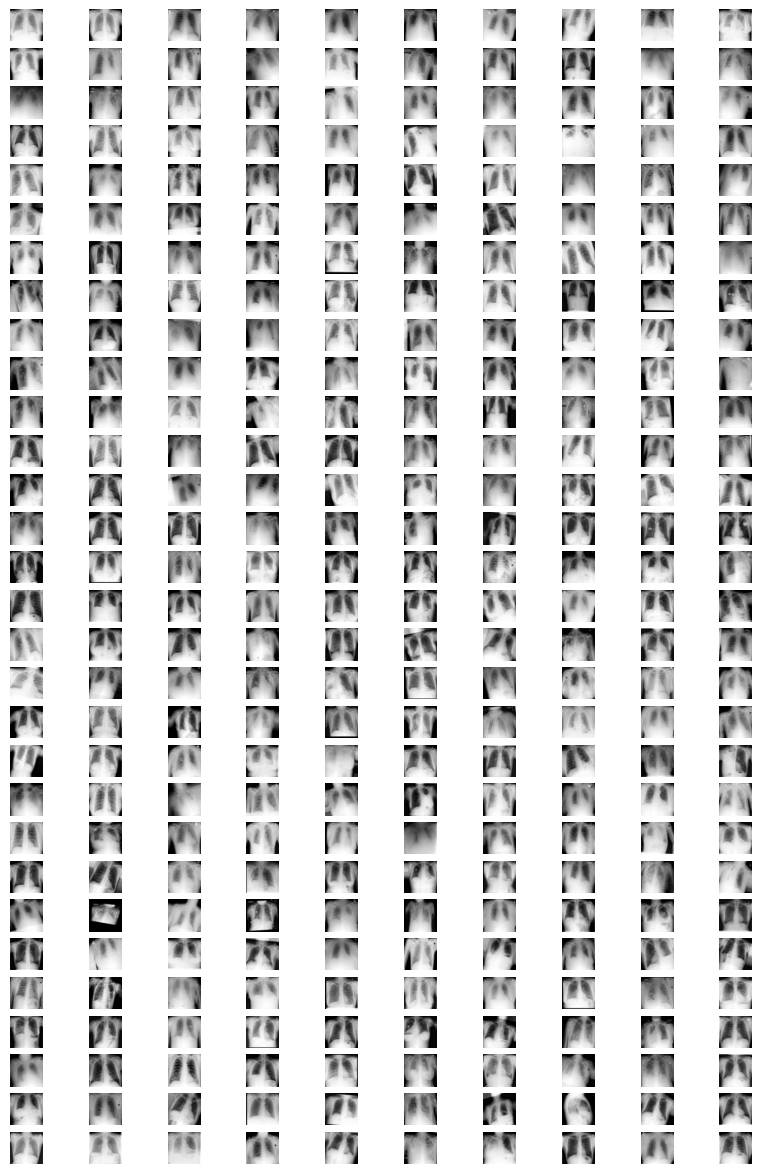

In [63]:
X_lowest = X_train[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 15))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(64, 64), cmap="gray", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [64]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [65]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = np.argmax(y_lowest, axis=1)

In [66]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_test, np.argmax(y_test, axis=1))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 4s, sys: 60.8 ms, total: 1min 4s
Wall time: 38.9 s


0.5080016047786743